# AI Labour Market Exposure: An Empirical Analysis of the Anthropic Economic Index

### Imports and Reading Data

In [203]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
sns.set_theme()

In [2]:
automation_vs_augmentation = pd.read_csv("data/automation_vs_augmentation.csv")
bls_employment = pd.read_csv("data/bls_employment_may_2023.csv")
task_mappings = pd.read_csv("data/onet_task_mappings.csv")
task_statements = pd.read_csv("data/onet_task_statements.csv")
soc_structure = pd.read_csv("data/SOC_Structure.csv")
wage_data = pd.read_csv("data/wage_data.csv")

### Data Understanding

In [3]:
print(f"automation_vs_augmentation shape: {automation_vs_augmentation.shape}")
print(f"bls_employment shape: {bls_employment.shape}")
print(f"task_mappings shape: {task_mappings.shape}")
print(f"task_statements shape: {task_statements.shape}")
print(f"soc_structure shape: {soc_structure.shape}")
print(f"wage_data shape: {wage_data.shape}")

automation_vs_augmentation shape: (6, 2)
bls_employment shape: (22, 2)
task_mappings shape: (3514, 2)
task_statements shape: (19530, 8)
soc_structure shape: (1596, 6)
wage_data shape: (1090, 10)


In [4]:
automation_vs_augmentation.head()

,interaction_type,pct
0,directive,22.563272
1,feedback loop,12.036303
2,learning,18.917648
3,none,2.901302
4,task iteration,25.476487


In [5]:
bls_employment.head()

,SOC or O*NET-SOC 2019 Title,bls_distribution
0,Management Occupations,10495770
1,Business and Financial Operations Occupations,10087830
2,Computer and Mathematical Occupations,5177400
3,Architecture and Engineering Occupations,2539660
4,"Life, Physical, and Social Science Occupations",1389430


In [6]:
task_mappings.head()

,task_name,pct
0,act as advisers to student organizations.,0.006775
1,act as an advocate for farmers or farmers' gro...,0.002997
2,act as an intermediary in negotiations between...,0.012638
3,act as an intermediary in negotiations between...,0.011466
4,act as liaisons between clients and medical st...,0.001954


In [7]:
task_statements.head()

,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,87.0,07/2014,Incumbent
1,11-1011.00,Chief Executives,8831,Appoint department heads or managers and assig...,Core,87.0,07/2014,Incumbent
2,11-1011.00,Chief Executives,8825,Analyze operations to evaluate performance of ...,Core,87.0,07/2014,Incumbent
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,87.0,07/2014,Incumbent
4,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,87.0,07/2014,Incumbent


In [8]:
soc_structure.head()

,Major Group,Minor Group,Broad Occupation,Detailed Occupation,Detailed O*NET-SOC,SOC or O*NET-SOC 2019 Title
0,11-0000,NaN,NaN,NaN,NaN,Management Occupations
1,NaN,11-1000,NaN,NaN,NaN,Top Executives
2,NaN,NaN,11-1010,NaN,NaN,Chief Executives
3,NaN,NaN,NaN,11-1011,NaN,Chief Executives
4,NaN,NaN,NaN,NaN,11-1011.03,Chief Sustainability Officers


In [9]:
wage_data.head()

,SOCcode,JobName,JobFamily,isBright,isGreen,JobZone,MedianSalary,JobForecast,ChanceAuto,WageGroup
0,13-2011.01,Accountants,Business and Financial Operations,True,False,4,70500.00,146000,-1.0,Accountants and Auditors
1,13-2011.00,Accountants and Auditors,Business and Financial Operations,True,False,-1,70500.00,146000,94.0,NaN
2,27-2011.00,Actors,"Arts, Design, Entertainment, Sports, and Media",False,False,2,17.54,7700,37.0,NaN
3,15-2011.00,Actuaries,Computer and Mathematical,True,False,4,102880.00,2200,21.0,NaN
4,29-1199.01,Acupuncturists,Healthcare Practitioners and Technical,True,False,5,73960.00,3400,-1.0,"Health Diagnosing and Treating Practitioners, ..."


In [10]:
automation_vs_augmentation.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   interaction_type  6 non-null      str    
 1   pct               6 non-null      float64
dtypes: float64(1), str(1)
memory usage: 228.0 bytes


In [11]:
bls_employment.info()

<class 'pandas.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 2 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   SOC or O*NET-SOC 2019 Title  22 non-null     str  
 1   bls_distribution             22 non-null     int64
dtypes: int64(1), str(1)
memory usage: 484.0 bytes


In [12]:
task_mappings.info()

<class 'pandas.DataFrame'>
RangeIndex: 3514 entries, 0 to 3513
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   task_name  3514 non-null   str    
 1   pct        3514 non-null   float64
dtypes: float64(1), str(1)
memory usage: 55.0 KB


In [13]:
task_statements.info()

<class 'pandas.DataFrame'>
RangeIndex: 19530 entries, 0 to 19529
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   O*NET-SOC Code         19530 non-null  str    
 1   Title                  19530 non-null  str    
 2   Task ID                19530 non-null  int64  
 3   Task                   19530 non-null  str    
 4   Task Type              18872 non-null  str    
 5   Incumbents Responding  18872 non-null  float64
 6   Date                   19530 non-null  str    
 7   Domain Source          19530 non-null  str    
dtypes: float64(1), int64(1), str(6)
memory usage: 1.2 MB


In [14]:
soc_structure.info()

<class 'pandas.DataFrame'>
RangeIndex: 1596 entries, 0 to 1595
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Major Group                  23 non-null     str  
 1   Minor Group                  98 non-null     str  
 2   Broad Occupation             459 non-null    str  
 3   Detailed Occupation          867 non-null    str  
 4   Detailed O*NET-SOC           149 non-null    str  
 5   SOC or O*NET-SOC 2019 Title  1596 non-null   str  
dtypes: str(6)
memory usage: 74.9 KB


In [15]:
wage_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1090 entries, 0 to 1089
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SOCcode       1090 non-null   str    
 1   JobName       1090 non-null   str    
 2   JobFamily     1090 non-null   str    
 3   isBright      1090 non-null   bool   
 4   isGreen       1090 non-null   bool   
 5   JobZone       1090 non-null   int64  
 6   MedianSalary  1090 non-null   float64
 7   JobForecast   1090 non-null   int64  
 8   ChanceAuto    1090 non-null   float64
 9   WageGroup     295 non-null    str    
dtypes: bool(2), float64(2), int64(2), str(4)
memory usage: 70.4 KB


In [16]:
automation_vs_augmentation.isna().sum()

interaction_type    0
pct                 0
dtype: int64

In [17]:
bls_employment.isna().sum()

SOC or O*NET-SOC 2019 Title    0
bls_distribution               0
dtype: int64

In [18]:
task_mappings.isna().sum()

task_name    0
pct          0
dtype: int64

In [19]:
task_statements.isna().sum()

O*NET-SOC Code             0
Title                      0
Task ID                    0
Task                       0
Task Type                658
Incumbents Responding    658
Date                       0
Domain Source              0
dtype: int64

In [20]:
soc_structure.isna().sum()

Major Group                    1573
Minor Group                    1498
Broad Occupation               1137
Detailed Occupation             729
Detailed O*NET-SOC             1447
SOC or O*NET-SOC 2019 Title       0
dtype: int64

In [21]:
wage_data.isna().sum()

SOCcode           0
JobName           0
JobFamily         0
isBright          0
isGreen           0
JobZone           0
MedianSalary      0
JobForecast       0
ChanceAuto        0
WageGroup       795
dtype: int64

In [22]:
task_statements["O*NET-SOC Code"].head()

0    11-1011.00
1    11-1011.00
2    11-1011.00
3    11-1011.00
4    11-1011.00
Name: O*NET-SOC Code, dtype: str

In [23]:
soc_structure["Major Group"].head()

0    11-0000
1        NaN
2        NaN
3        NaN
4        NaN
Name: Major Group, dtype: str

### Merging O*NET-SOC Code with Major Group

In [24]:
# Clean soc_structure by dropping all NaN values from Major Group column
soc_structure_clean = soc_structure.dropna(subset=["Major Group"])

# Create matching key column for both tables and only take first 2 characters of each column for major occupational group
task_statements["soc_major_group"] = task_statements["O*NET-SOC Code"].str[:2]
soc_structure_clean["soc_major_group"] = soc_structure_clean["Major Group"].str[:2]

# Join the two DataFrame's with a merge
task_occupations = task_statements.merge(
    soc_structure_clean[["soc_major_group", "SOC or O*NET-SOC 2019 Title"]],
    on="soc_major_group",
    how="left"
)

In [25]:
task_occupations.head()

,O*NET-SOC Code,Title,Task ID,Task,Task Type,Incumbents Responding,Date,Domain Source,soc_major_group,SOC or O*NET-SOC 2019 Title
0,11-1011.00,Chief Executives,8823,Direct or coordinate an organization's financi...,Core,87.0,07/2014,Incumbent,11,Management Occupations
1,11-1011.00,Chief Executives,8831,Appoint department heads or managers and assig...,Core,87.0,07/2014,Incumbent,11,Management Occupations
2,11-1011.00,Chief Executives,8825,Analyze operations to evaluate performance of ...,Core,87.0,07/2014,Incumbent,11,Management Occupations
3,11-1011.00,Chief Executives,8826,"Direct, plan, or implement policies, objective...",Core,87.0,07/2014,Incumbent,11,Management Occupations
4,11-1011.00,Chief Executives,8827,"Prepare budgets for approval, including those ...",Core,87.0,07/2014,Incumbent,11,Management Occupations


In [26]:
# Drop unnecessary columns
task_occupations = task_occupations[['O*NET-SOC Code',
                                     'Title',
                                   # 'Task ID',
                                     'Task',
                                   # 'Task Type',
                                   # 'Incumbents Responding',
                                   # 'Date',
                                   # 'Domain Source',
                                     'soc_major_group',
                                     'SOC or O*NET-SOC 2019 Title']]

In [27]:
task_occupations.head()

,O*NET-SOC Code,Title,Task,soc_major_group,SOC or O*NET-SOC 2019 Title
0,11-1011.00,Chief Executives,Direct or coordinate an organization's financi...,11,Management Occupations
1,11-1011.00,Chief Executives,Appoint department heads or managers and assig...,11,Management Occupations
2,11-1011.00,Chief Executives,Analyze operations to evaluate performance of ...,11,Management Occupations
3,11-1011.00,Chief Executives,"Direct, plan, or implement policies, objective...",11,Management Occupations
4,11-1011.00,Chief Executives,"Prepare budgets for approval, including those ...",11,Management Occupations


In [28]:
task_occupations.shape

(19530, 5)

In [29]:
task_occupations.isna().sum()

O*NET-SOC Code                 0
Title                          0
Task                           0
soc_major_group                0
SOC or O*NET-SOC 2019 Title    0
dtype: int64

### Join Claude Usage Data to Occupations

In [30]:
task_mappings["task_name"]

0               act as advisers to student organizations.
1       act as an advocate for farmers or farmers' gro...
2       act as an intermediary in negotiations between...
3       act as an intermediary in negotiations between...
4       act as liaisons between clients and medical st...
                              ...                        
3509    write, design, or edit web page content, or di...
3510    write, present, and publish reports that recor...
3511    write, review, or execute plans for testing ne...
3512    write, review, or maintain engineering documen...
3513    write, update, and maintain computer programs ...
Name: task_name, Length: 3514, dtype: str

In [31]:
task_occupations["Task"]

0        Direct or coordinate an organization's financi...
1        Appoint department heads or managers and assig...
2        Analyze operations to evaluate performance of ...
3        Direct, plan, or implement policies, objective...
4        Prepare budgets for approval, including those ...
                               ...                        
19525    Test vessels for leaks, damage, and defects, a...
19526    Unload cars containing liquids by connecting h...
19527    Copy and attach load specifications to loaded ...
19528    Start pumps and adjust valves or cables to reg...
19529    Perform general warehouse activities, such as ...
Name: Task, Length: 19530, dtype: str

In [32]:
# Create matching key column for both tables and keep formatting consistent
task_mappings["Task"] = task_mappings["task_name"].str.lower().str.strip()
task_occupations["Task"] = task_occupations["Task"].str.lower().str.strip()

# Join the two DataFrame's with a merge
task_usage = task_mappings.merge(
    task_occupations,
    on="Task",
    how="left"
)

# Drop the task_name column
task_usage = task_usage.drop("task_name", axis=1)

In [33]:
task_usage.head()

,pct,Task,O*NET-SOC Code,Title,soc_major_group,SOC or O*NET-SOC 2019 Title
0,0.006775,act as advisers to student organizations.,25-1011.00,"Business Teachers, Postsecondary",25,Educational Instruction and Library Occupations
1,0.006775,act as advisers to student organizations.,25-1021.00,"Computer Science Teachers, Postsecondary",25,Educational Instruction and Library Occupations
2,0.006775,act as advisers to student organizations.,25-1022.00,"Mathematical Science Teachers, Postsecondary",25,Educational Instruction and Library Occupations
3,0.006775,act as advisers to student organizations.,25-1031.00,"Architecture Teachers, Postsecondary",25,Educational Instruction and Library Occupations
4,0.006775,act as advisers to student organizations.,25-1032.00,"Engineering Teachers, Postsecondary",25,Educational Instruction and Library Occupations


In [34]:
# Compute the scaled pct by grouping the data
task_usage["n_occurrences"] = task_usage.groupby("Task")["Title"].transform("nunique")
task_usage["pct_scaled"] = task_usage["pct"] / task_usage["n_occurrences"]

# Rename pct to pct_raw for clarity
task_usage = task_usage.rename(columns={"pct": "pct_raw"})

In [35]:
task_usage.head()

,pct_raw,Task,O*NET-SOC Code,Title,soc_major_group,SOC or O*NET-SOC 2019 Title,n_occurrences,pct_scaled
0,0.006775,act as advisers to student organizations.,25-1011.00,"Business Teachers, Postsecondary",25,Educational Instruction and Library Occupations,34,0.000199
1,0.006775,act as advisers to student organizations.,25-1021.00,"Computer Science Teachers, Postsecondary",25,Educational Instruction and Library Occupations,34,0.000199
2,0.006775,act as advisers to student organizations.,25-1022.00,"Mathematical Science Teachers, Postsecondary",25,Educational Instruction and Library Occupations,34,0.000199
3,0.006775,act as advisers to student organizations.,25-1031.00,"Architecture Teachers, Postsecondary",25,Educational Instruction and Library Occupations,34,0.000199
4,0.006775,act as advisers to student organizations.,25-1032.00,"Engineering Teachers, Postsecondary",25,Educational Instruction and Library Occupations,34,0.000199


In [36]:
task_usage.shape

(4245, 8)

In [37]:
task_usage.isna().sum()

pct_raw                        0
Task                           0
O*NET-SOC Code                 1
Title                          1
soc_major_group                1
SOC or O*NET-SOC 2019 Title    1
n_occurrences                  0
pct_scaled                     0
dtype: int64

In [38]:
task_usage[task_usage["O*NET-SOC Code"].isna()]

,pct_raw,Task,O*NET-SOC Code,Title,soc_major_group,SOC or O*NET-SOC 2019 Title,n_occurrences,pct_scaled
2482,0.481557,none,NaN,NaN,NaN,NaN,0,inf


In [39]:
task_usage = task_usage[task_usage["Task"] != "none"]

### Merge in BLS Employment Data

In [40]:
# Match granularity task_usage to bls_employment
category_usage = (
    task_usage
    .groupby("SOC or O*NET-SOC 2019 Title")["pct_scaled"]
    .sum()
    .reset_index()
)

In [41]:
# Merge bls_employment to category_usage
category_comparison = category_usage.merge(
    bls_employment,
    on="SOC or O*NET-SOC 2019 Title",
    how="left"
)

In [42]:
# Add column for percentage of total employment
category_comparison["bls_pct"] = 100 * category_comparison["bls_distribution"] / category_comparison["bls_distribution"].sum()

# Add column to show over/under representation of AI usage per category
category_comparison["bls_pct_diff"] = category_comparison["pct_scaled"] - category_comparison["bls_pct"]

# Add column to show relative AI usage per category
category_comparison["bls_pct_ratio"] = category_comparison["pct_scaled"] / category_comparison["bls_pct"]

In [43]:
category_comparison.head()

,SOC or O*NET-SOC 2019 Title,pct_scaled,bls_distribution,bls_pct,bls_pct_diff,bls_pct_ratio
0,Architecture and Engineering Occupations,4.492189,2539660,1.672437,2.819752,2.686014
1,"Arts, Design, Entertainment, Sports, and Media...",10.227880,2106490,1.387182,8.840697,7.373133
2,Building and Grounds Cleaning and Maintenance ...,0.098240,4429070,2.916666,-2.818426,0.033682
3,Business and Financial Operations Occupations,5.899402,10087830,6.643117,-0.743715,0.888047
4,Community and Social Service Occupations,2.064090,2418130,1.592406,0.471684,1.296209


In [44]:
category_comparison.shape

(22, 6)

In [45]:
category_comparison.isna().sum()

SOC or O*NET-SOC 2019 Title    0
pct_scaled                     0
bls_distribution               0
bls_pct                        0
bls_pct_diff                   0
bls_pct_ratio                  0
dtype: int64

### Merge in Wage Data

In [46]:
occupation_usage = (
    task_usage
    .groupby(["O*NET-SOC Code", "Title"])["pct_scaled"]
    .sum()
    .reset_index()
)

In [47]:
occupation_comparison = occupation_usage.merge(
    wage_data,
    left_on="O*NET-SOC Code",
    right_on="SOCcode",
    how="left"
)

In [48]:
occupation_comparison.head()

,O*NET-SOC Code,Title,pct_scaled,SOCcode,JobName,JobFamily,isBright,isGreen,JobZone,MedianSalary,JobForecast,ChanceAuto,WageGroup
0,11-1011.00,Chief Executives,0.382927,11-1011.00,Chief Executives,Management,False,False,5,189600.0,16800,1.5,NaN
1,11-1011.03,Chief Sustainability Officers,0.006515,11-1011.03,Chief Sustainability Officers,Management,False,True,5,189600.0,16800,-1.0,Chief Executives
2,11-1021.00,General and Operations Managers,0.124298,11-1021.00,General and Operations Managers,Management,True,True,4,100930.0,230000,16.0,NaN
3,11-1031.00,Legislators,0.031400,11-1031.00,Legislators,Management,False,False,4,24670.0,4300,-1.0,NaN
4,11-2011.00,Advertising and Promotions Managers,0.193613,11-2011.00,Advertising and Promotions Managers,Management,False,False,4,117130.0,2700,4.0,NaN


In [49]:
occupation_comparison = occupation_comparison[['O*NET-SOC Code', 'Title', 'pct_scaled',
                                             # 'SOCcode', 'JobName', 'JobFamily',
                                             # 'isBright', 'isGreen', 'JobZone',
                                               'MedianSalary',
                                             # 'JobForecast', 'ChanceAuto', 'WageGroup'
                                             ]]

In [50]:
occupation_comparison.head()

,O*NET-SOC Code,Title,pct_scaled,MedianSalary
0,11-1011.00,Chief Executives,0.382927,189600.0
1,11-1011.03,Chief Sustainability Officers,0.006515,189600.0
2,11-1021.00,General and Operations Managers,0.124298,100930.0
3,11-1031.00,Legislators,0.031400,24670.0
4,11-2011.00,Advertising and Promotions Managers,0.193613,117130.0


In [51]:
occupation_comparison.shape

(756, 4)

In [52]:
occupation_comparison.isna().sum()

O*NET-SOC Code    0
Title             0
pct_scaled        0
MedianSalary      0
dtype: int64

## Data Visualisation

In [99]:
# sort category_comparison by bls_pct_diff
category_comparison_sorted_diff = category_comparison.sort_values(by="bls_pct_diff")

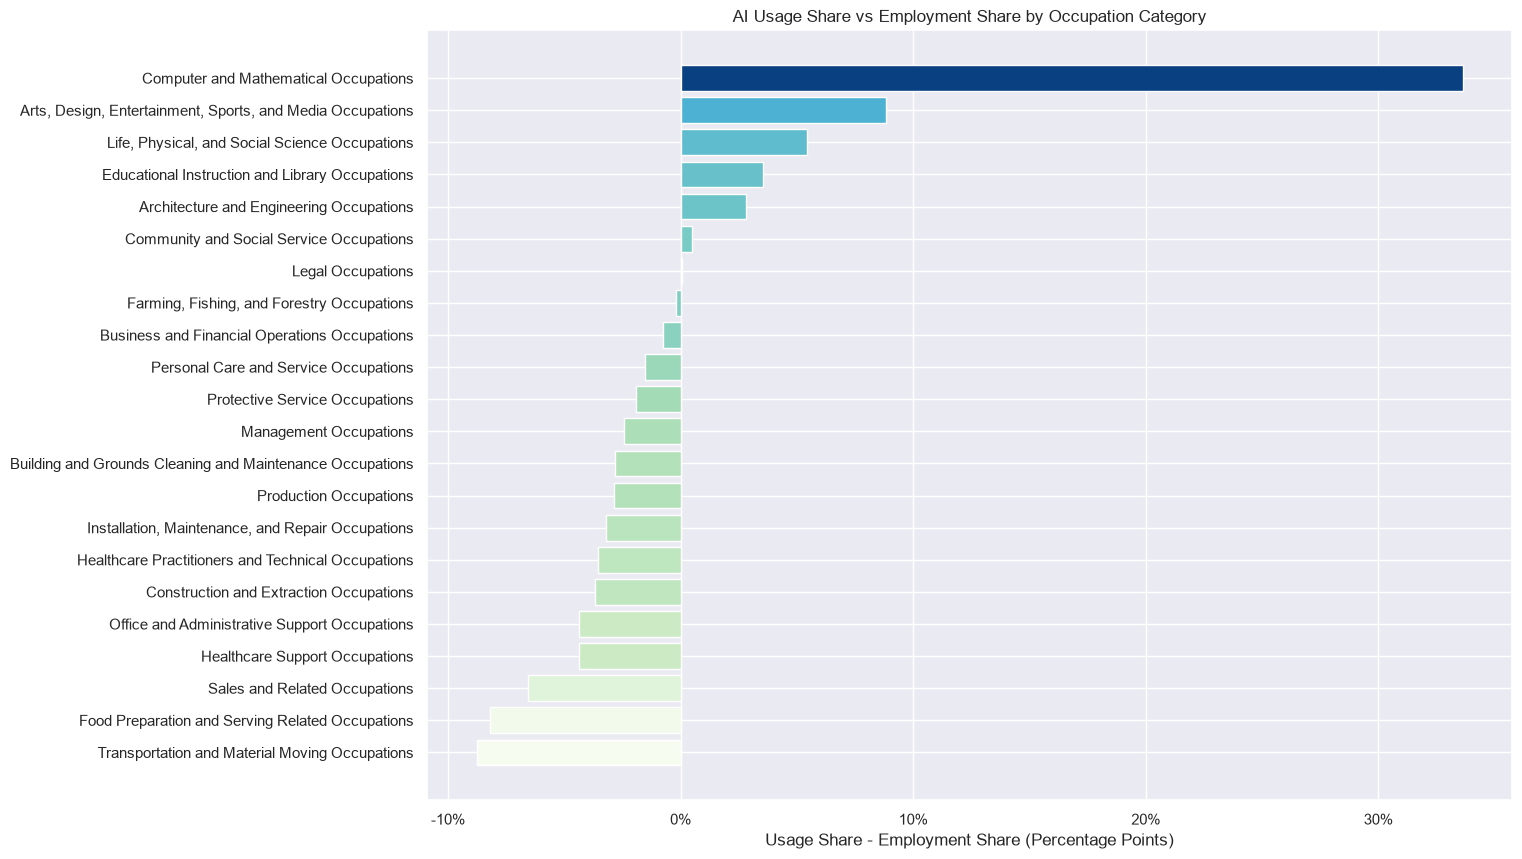

In [223]:
norm = mcolors.TwoSlopeNorm(
    vmin=category_comparison_sorted_diff["bls_pct_diff"].min(),
    vcenter=0,
    vmax=category_comparison_sorted_diff["bls_pct_diff"].max()
    )
colors = plt.cm.GnBu(norm(category_comparison_sorted_diff["bls_pct_diff"]))

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(category_comparison_sorted_diff["SOC or O*NET-SOC 2019 Title"], category_comparison_sorted_diff["bls_pct_diff"], color=colors)
ax.set_title("AI Usage Share vs Employment Share by Occupation Category")
ax.set_xlabel("Usage Share - Employment Share (Percentage Points)")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
plt.show()

In [64]:
category_comparison.head(3)

,SOC or O*NET-SOC 2019 Title,pct_scaled,bls_distribution,bls_pct,bls_pct_diff,bls_pct_ratio
0,Architecture and Engineering Occupations,4.492189,2539660,1.672437,2.819752,2.686014
1,"Arts, Design, Entertainment, Sports, and Media...",10.227880,2106490,1.387182,8.840697,7.373133
2,Building and Grounds Cleaning and Maintenance ...,0.098240,4429070,2.916666,-2.818426,0.033682


In [ ]:
# log transformation column
category_comparison["log2_ratio"] = np.log2(category_comparison["bls_pct_ratio"])

# sort category_comparison by bls_pct_ratio
category_comparison_sorted_ratio = category_comparison.sort_values(by="bls_pct_ratio")

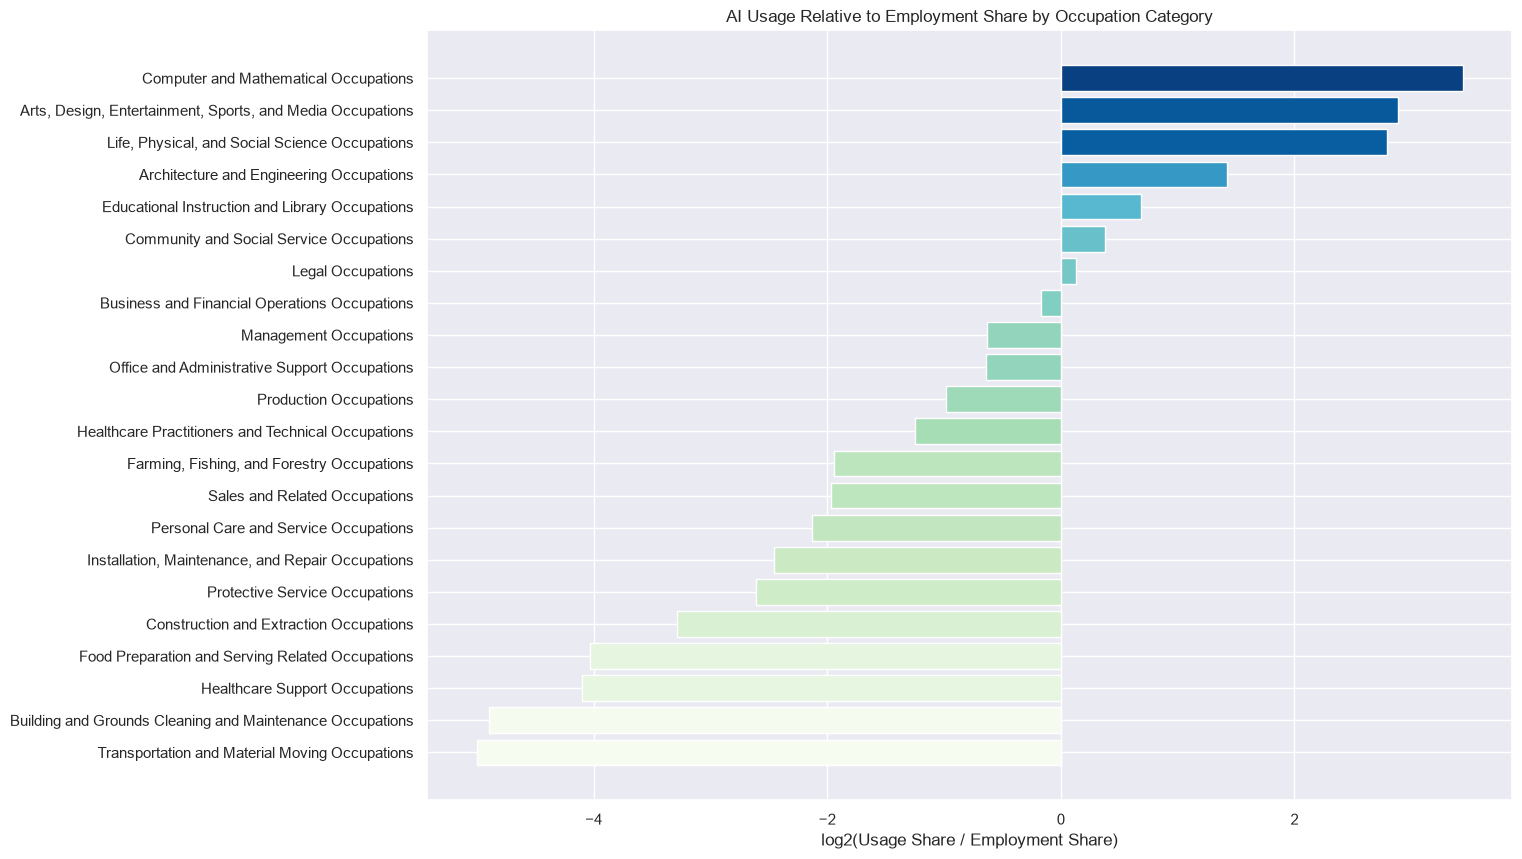

In [222]:
norm = mcolors.TwoSlopeNorm(
    vmin=category_comparison_sorted_ratio["log2_ratio"].min(),
    vcenter=0,
    vmax=category_comparison_sorted_ratio["log2_ratio"].max()
)
colors = plt.cm.GnBu(norm(category_comparison_sorted_ratio["log2_ratio"]))

fig, ax = plt.subplots(figsize=(14, 10))
ax.barh(category_comparison_sorted_ratio["SOC or O*NET-SOC 2019 Title"], category_comparison_sorted_ratio["log2_ratio"], color=colors)
ax.set_title("AI Usage Relative to Employment Share by Occupation Category")
ax.set_xlabel("log2(Usage Share / Employment Share)")
plt.show()

In [80]:
occupation_comparison["pct_scaled"].describe()

count    756.000000
mean       0.131638
std        0.417186
min        0.001954
25%        0.010684
50%        0.032117
75%        0.092051
max        6.128259
Name: pct_scaled, dtype: float64

In [81]:
occupation_comparison["MedianSalary"].describe()

count       756.000000
mean      64792.539881
std       34451.541311
min          16.310000
25%       40322.500000
50%       58825.000000
75%       79737.500000
max      208000.000000
Name: MedianSalary, dtype: float64

In [87]:
occupation_comparison[occupation_comparison["MedianSalary"] < 10000]

,O*NET-SOC Code,Title,pct_scaled,MedianSalary
352,27-2011.00,Actors,0.780446,17.54
360,27-2031.00,Dancers,0.004169,16.31
364,27-2042.01,Singers,0.034527,28.15
365,27-2042.02,"Musicians, Instrumental",0.016026,28.15


In [89]:
occupation_comparison.loc[occupation_comparison["MedianSalary"] < 1000, "MedianSalary"] *= 2080
occupation_comparison[occupation_comparison["MedianSalary"] < 10000]

,O*NET-SOC Code,Title,pct_scaled,MedianSalary


In [79]:
occupation_comparison["pct_scaled"].corr(occupation_comparison["MedianSalary"])

np.float64(0.08696115024874321)

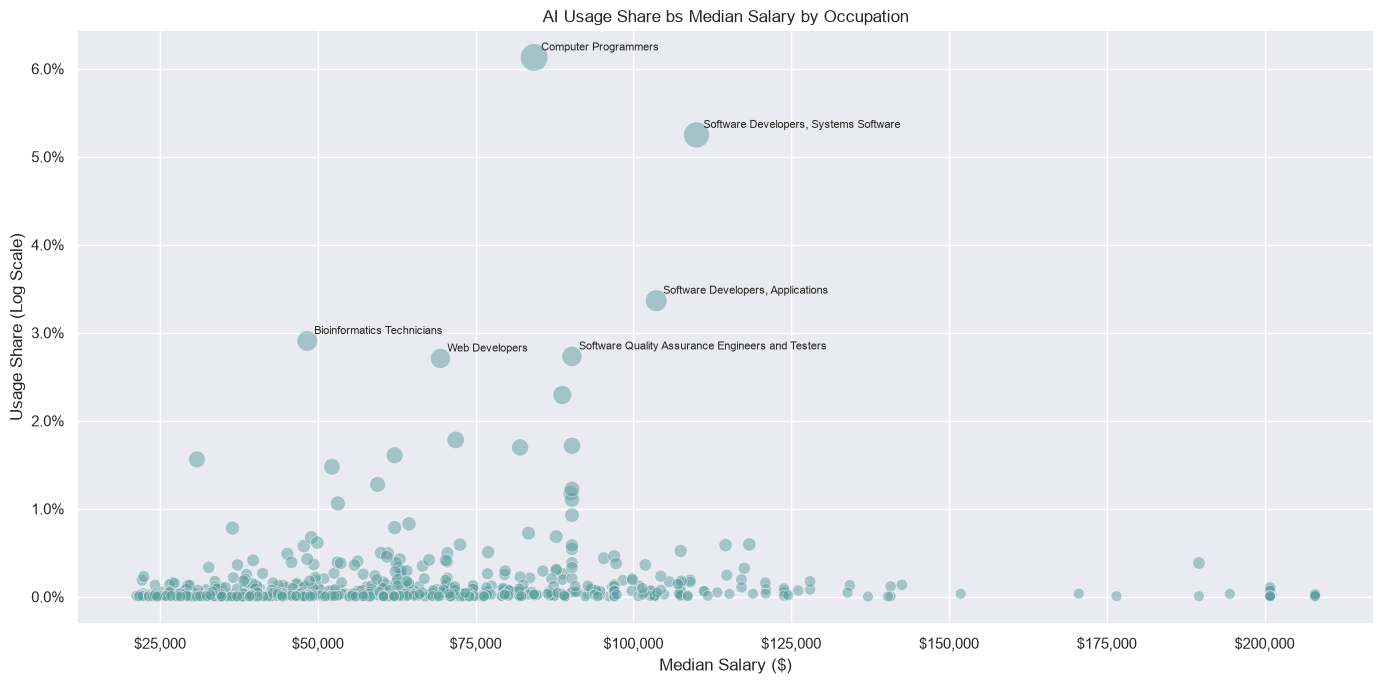

In [216]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.scatterplot(data=occupation_comparison, x="MedianSalary", y="pct_scaled",
                size="pct_scaled", sizes=(60, 400), alpha=0.5, legend=False,
                color="cadetblue", ax=ax)

ax.set_xlabel("Median Salary ($)")
ax.set_ylabel("Usage Share (Log Scale)")
ax.set_title("AI Usage Share bs Median Salary by Occupation")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.1f}%"))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))

top_n = occupation_comparison.nlargest(6, "pct_scaled")
for _, row in top_n.iterrows():
    ax.annotate(row["Title"], (row["MedianSalary"], row["pct_scaled"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)

plt.tight_layout()
plt.show()

In [111]:
automation_vs_augmentation

,interaction_type,pct
0,directive,22.563272
1,feedback loop,12.036303
2,learning,18.917648
3,none,2.901302
4,task iteration,25.476487
5,validation,2.314220


In [112]:
automation_vs_augmentation["pct"].sum()

np.float64(84.20923280635584)

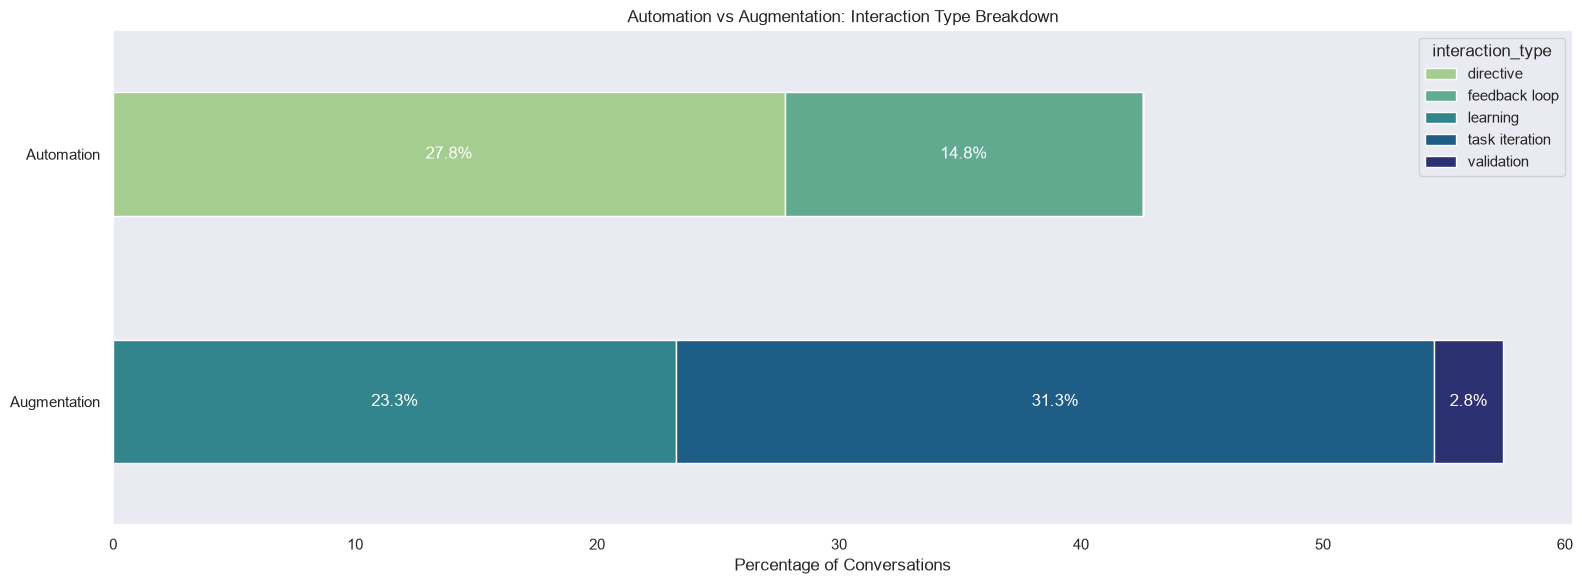

In [225]:
avg_df = automation_vs_augmentation[automation_vs_augmentation["interaction_type"] != "none"].copy()
avg_df["pct_normalised"] = 100 * avg_df["pct"] / avg_df["pct"].sum()

supercategory_map = {
    "directive": "Automation",
    "feedback loop": "Automation",
    "learning": "Augmentation",
    "task iteration": "Augmentation",
    "validation": "Augmentation"
}

avg_df["supercategory"] = avg_df["interaction_type"].map(supercategory_map)

pivot_df = avg_df.pivot(index="supercategory", columns="interaction_type", values="pct_normalised").fillna(0)

fig, ax = plt.subplots(figsize=(16, 6))
pivot_df.plot(kind="barh", stacked=True, colormap="crest", ax=ax)
for container in ax.containers:
    labels = [f"{v:.1f}%" if v > 0 else "" for v in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", color="white")

ax.set_xlabel("Percentage of Conversations")
ax.set_ylabel("")
ax.set_title("Automation vs Augmentation: Interaction Type Breakdown")
plt.grid(False)
plt.tight_layout()
plt.show()